## EDA



## Import data

In [2]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = '/content/drive/My Drive/data-science/hotel_bookings.csv'
df = pd.read_csv(file_path)

# Check
print(df.shape)
df.head()

Mounted at /content/drive
(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Missing values

In [3]:
df["hotel"].unique()
# TODO remove hotel, make is_resort

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [4]:
df["is_canceled"].unique()

array([0, 1])

<Axes: >

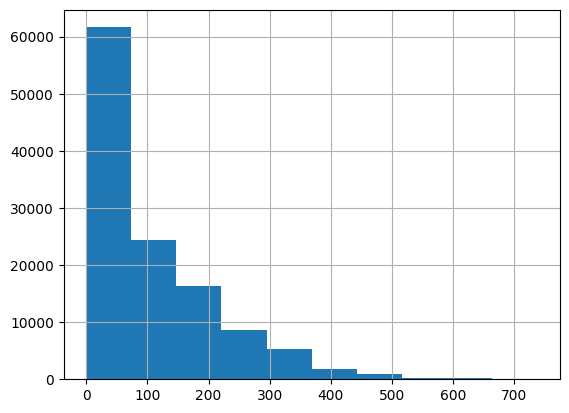

In [5]:
df["lead_time"].hist()

In [6]:
df["arrival_date_year"].unique()

array([2015, 2016, 2017])

In [7]:
df["arrival_date_month"].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [8]:
df["arrival_date_week_number"].unique()

array([27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
       25, 26])

<Axes: >

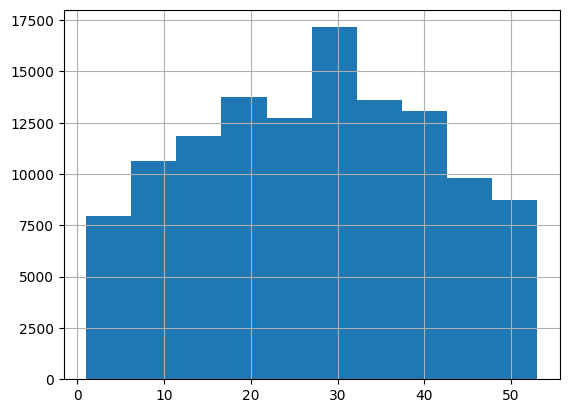

In [9]:
df["arrival_date_week_number"].hist()

<Axes: >

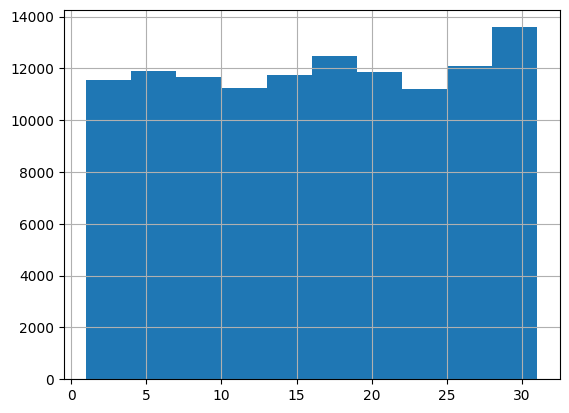

In [14]:
df["arrival_date_day_of_month"].hist()

In [15]:
# Inspect data shape and columns
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (119390, 32)

Columns:
 ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


<Axes: >

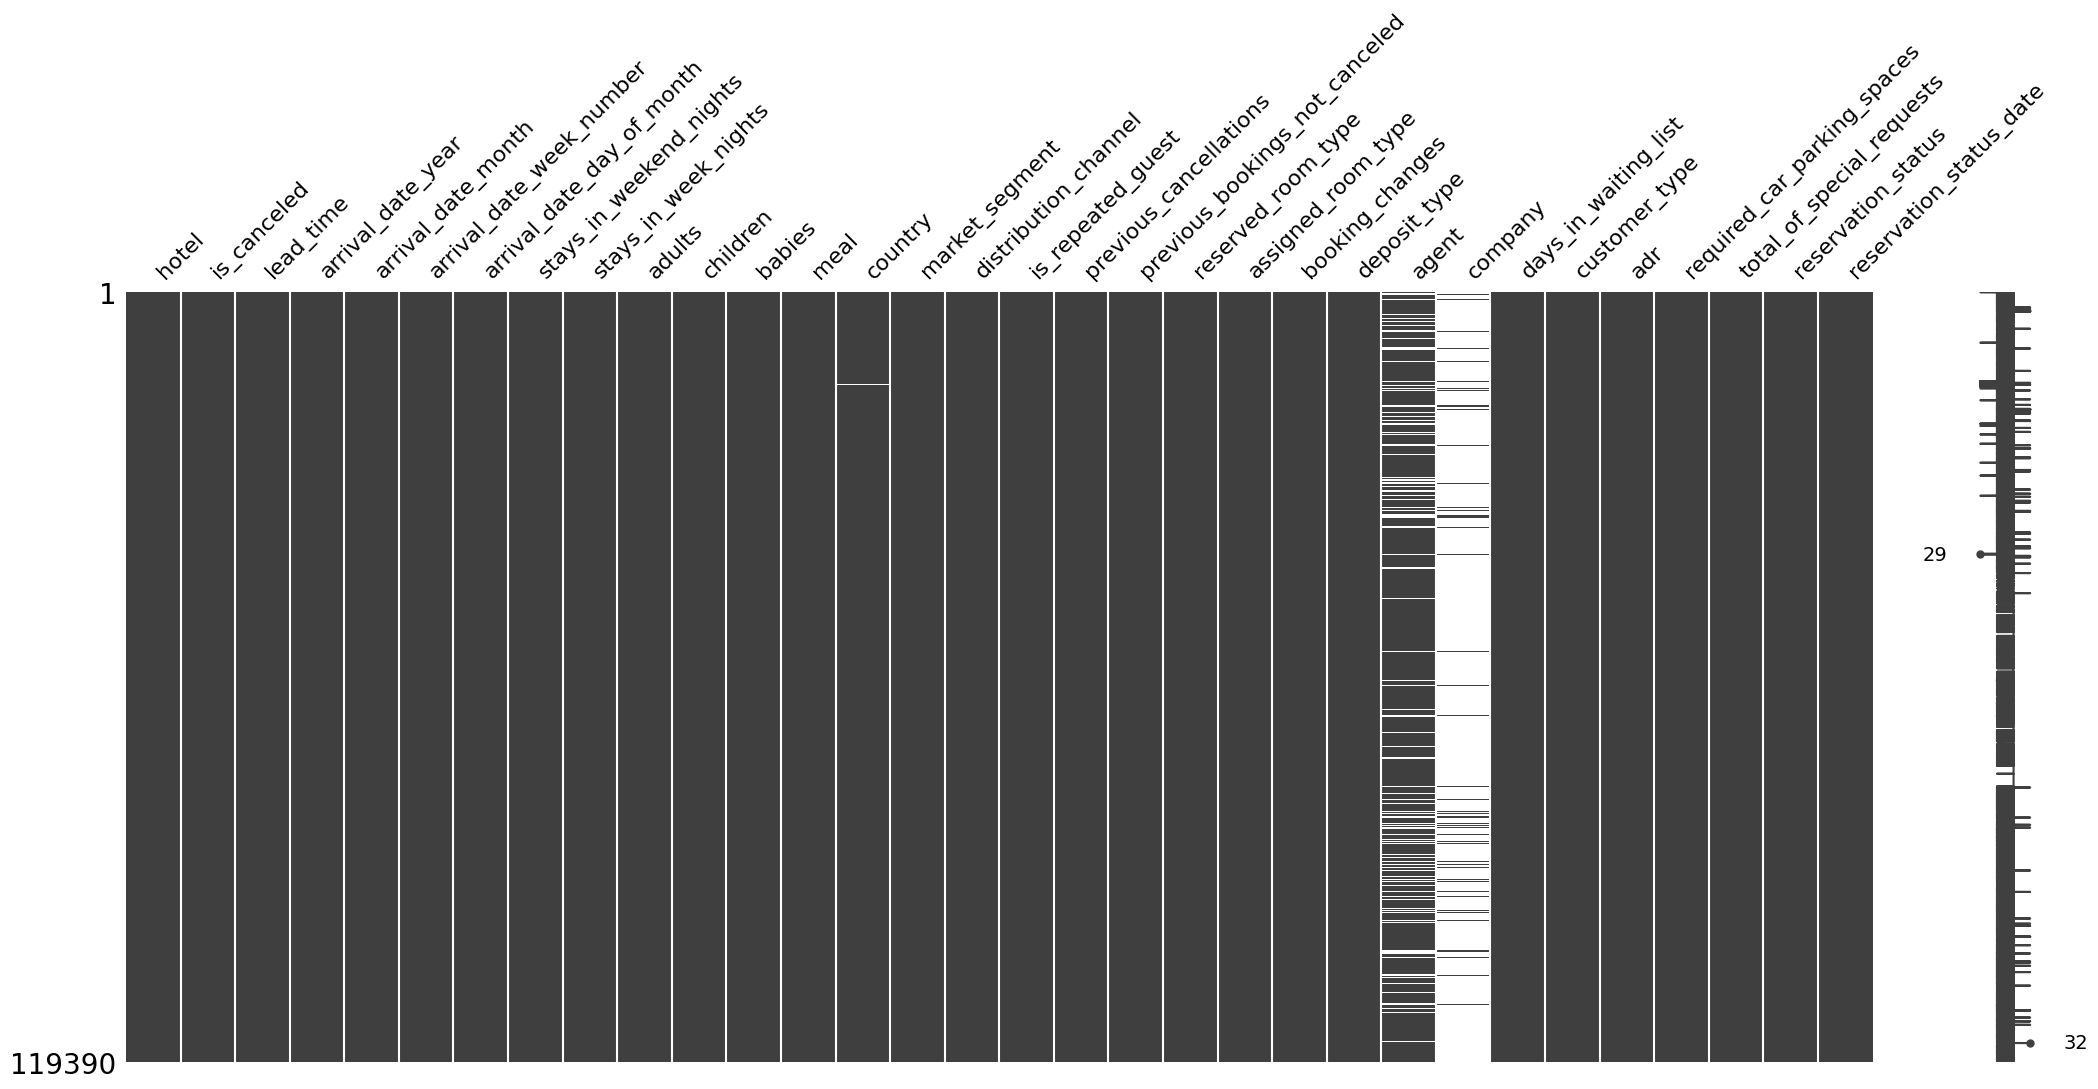

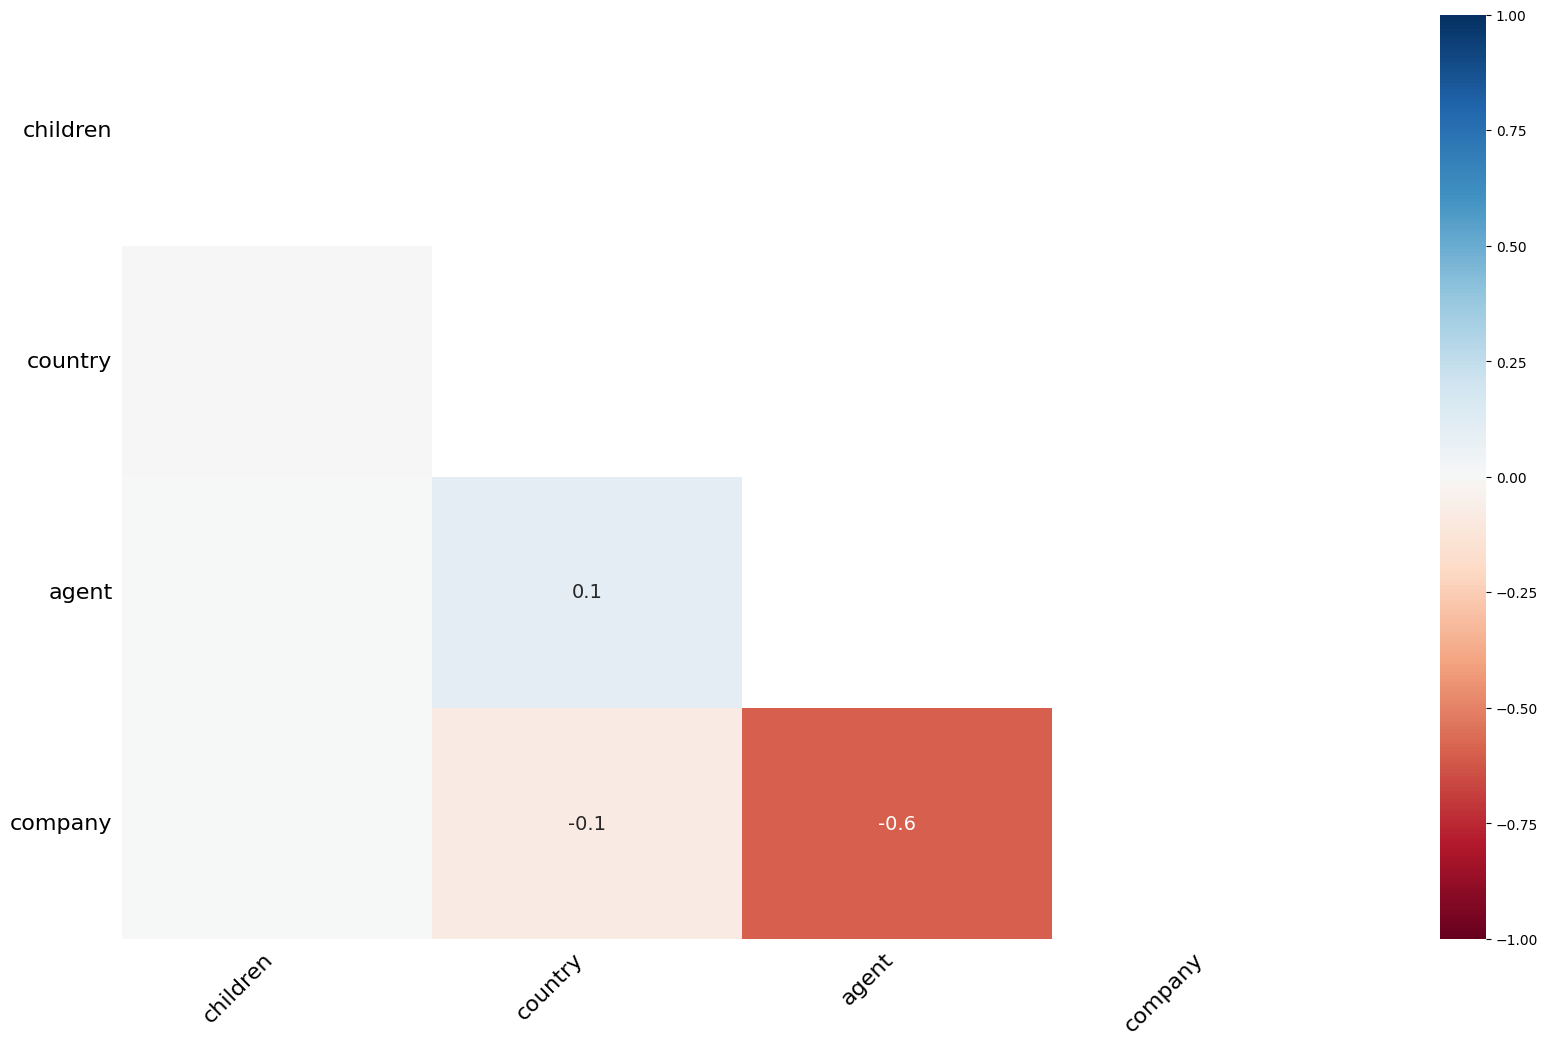

In [28]:
!pip install missingno -q
import missingno as msno

msno.matrix(df)
msno.heatmap(df)

In [16]:
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False))


Missing values per column:
company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations       

In [20]:
# Percentage of missing
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print("\nMissing values (%):")
print(missing_pct)


Missing values (%):
company                           94.306893
agent                             13.686238
country                            0.408744
children                           0.003350
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
hotel                              0.000000
is_canceled                        0.000000
stays_in_weekend_nights            0.000000
arrival_date_day_of_month          0.000000
adults                             0.000000
stays_in_week_nights               0.000000
babies                             0.000000
meal                               0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
distribution_channel               0.000000
market_segment                     0.000000
previous_bookings_not_canceled     0.000000
is_repeated_guest                  0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_cha

company - drop the column
agent - engineer a feature “booked through agent vs direct.”
country - Fill missing with "Unknown" (safe, interpretable).
children - Fill missing with 0 (Alternatively, drop the rows)

## Reports

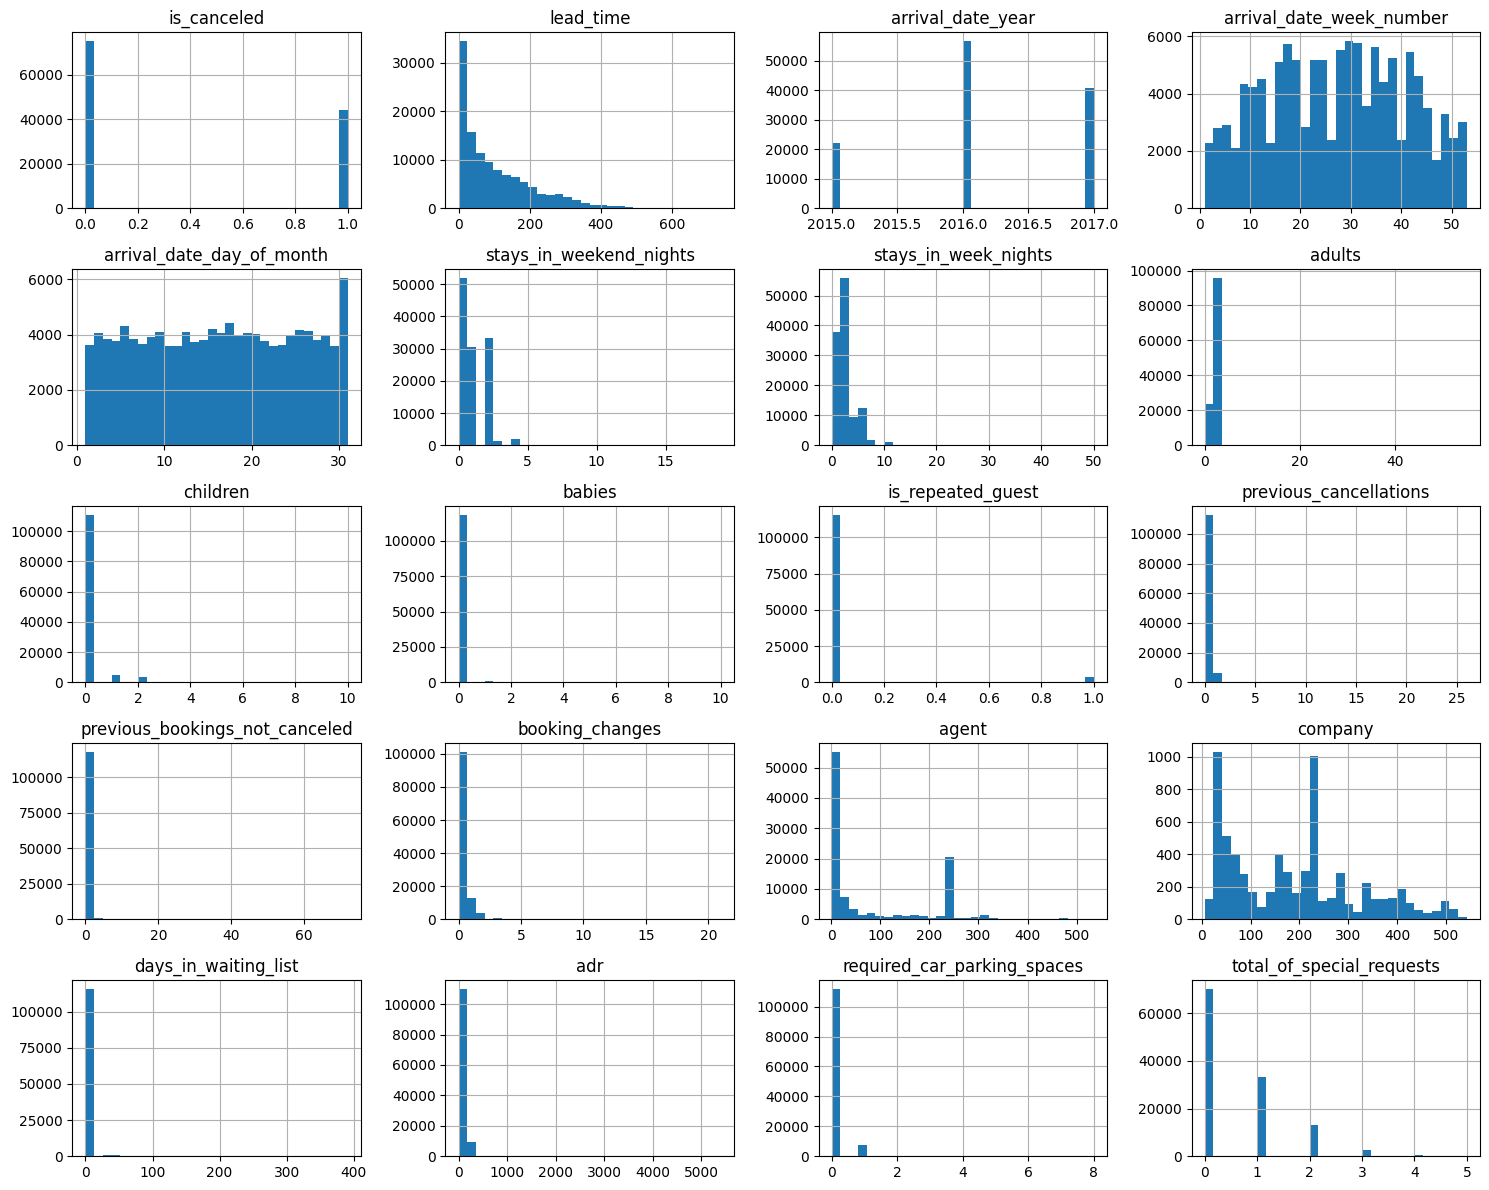

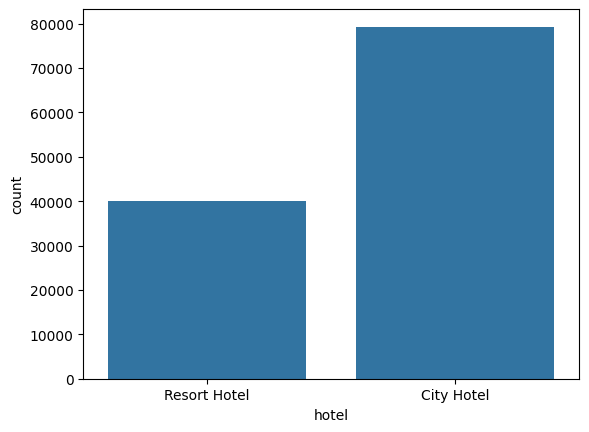

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numeric columns histogram
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

# Categorical count plot example
sns.countplot(x="hotel", data=df)
plt.show()

In [25]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [ ]:
# !pip install -U ydata-profiling -q

# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Hotel Bookings EDA Report", explorative=True)

# # Render inline without ipywidgets
# profile.to_notebook_iframe()
# # Or save to file:
# # profile.to_file("hotel_eda_report.html")